### CD4 T-cell Milo Differential Abundance Analysis: Age Effect
*Dataset: PICA Batch001–Batch007 (PICA0001–PICA0128)* \
*Analysis: Lineage-specific age-associated neighbourhood 
differential abundance*

#### Background
Milo identifies local neighbourhoods within the CD4 T-cell manifold that show age-associated changes in abundance while accounting for donor-level covariates and neighbourhood structure.

#### Aim
This notebook tests whether CD4 T-cell neighbourhood abundance changes with donor age using Milo.

*Note: This analysis was performed as a lineage-specific exploration of age-associated compositional changes within CD4 T cells. The primary differential abundance results reported in the thesis were derived from the full-cohort compositional analysis, while Milo was used to provide higher-resolution neighbourhood-level insights.*

In [1]:
import os
import mudata as mu
import anndata as ad
import pertpy as pt
import scanpy as sc
import pandas as pd
import mudata as mu
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

milo = pt.tl.Milo()

from pertpy.tools import Milo

In [2]:
mdata_cd4_age = mu.read("/scratch/user/s4575250/BIOX7014_Thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_milo_nhoods_built.h5mu")

In [3]:
mdata_cd4_age

MuData object with n_obs × n_vars = 596614 × 70755
  2 modalities
    rna:	596486 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Batch', 'Age_group', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'Batch_colors', 'Sex_colors', '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'neighbors', 'nhood_neighbors_key', 'pica_cell_type_complete_01_gdT_corrected_colors', 'pool_id_colors', 'sequencing_batch_colors', 'umap'
      obsm:	'X_scVI', 'X_umap', 'nhoods'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	128 x 32149
      obs:	'Age_years', 'Sex', 'Batch', 'Age', 'Age_group'
      var:	'ind

## Run Milo Differential Abundance Testing

In [ ]:
# Test for age-associated changes in CD4 neighbourhood abundance
# Batch and sex are included as covariates
milo.da_nhoods(
    mdata_cd4_age,
    design="~ Batch + Sex + Age_years",
    model_contrasts="Age_years",    
    solver="pydeseq2"                 
)

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
/home/s4575250/miniforge3/envs/milo/lib/python3.12/site-packages/pydeseq2/dds.py:539: UserWarning: Every gene contains at least one zero, cannot compute log geometric means. Switching to iterative mode.
  self.fit_size_factors(
Fitting dispersions...
... done in 6.77 seconds.

Fitting MAP dispersions...
... done in 6.07 seconds.

Fitting dispersions...
... done in 6.42 seconds.

Fitting MAP dispersions...
... done in 6.19 seconds.

Fitting dispersions...
... done in 6.83 seconds.

Fitting MAP dispersions...
... done in 6.69 seconds.

Fitting dispersions...
... done in 6.23 seconds.

Fitting MAP dispersions...
... done in 6.06 seconds.

Fitting dispersions...
... done in 6.68 seconds.

Fitting MAP dispersions...
... done in 6.24 seconds.

Fitting dispersions...
... done in 6.69 seconds.

Fitting MAP dispersions...
... done in 6.04 seconds.

Fitting dispersions...
... done in 6.66 seconds.

Fitting MAP dispersions...
... done in 6.30 seconds.

Fitting dispersions.

Log2 fold change & Wald test p-value: Age_years 17.03 vs 0.05
       baseMean  log2FoldChange     lfcSE      stat        pvalue  \
0      4.096742       -2.029535  0.439953 -4.613076  3.967530e-06   
1      4.456991        0.511779  0.535709  0.955330  3.394106e-01   
2      3.854566       -0.794999  0.647393 -1.228000  2.194470e-01   
3      3.749896        0.045126  0.446369  0.101095  9.194752e-01   
4      3.899418       -2.409885  0.452830 -5.321831  1.027281e-07   
...         ...             ...       ...       ...           ...   
32144  2.157312       -2.443140  0.577568 -4.230044  2.336451e-05   
32145  4.801573       -6.078893  0.830722 -7.317598  2.524486e-13   
32146  4.902330        0.392378  0.549090  0.714597  4.748580e-01   
32147  2.667069        1.228943  0.579942  2.119078  3.408387e-02   
32148  3.522144       -0.357766  0.581197 -0.615568  5.381796e-01   

               padj  
0      1.410507e-05  
1      4.123540e-01  
2      2.833220e-01  
3      9.377049e-01  

... done in 2.61 seconds.



In [5]:
mdata_cd4_age["milo"].var.columns.tolist()

['index_cell',
 'kth_distance',
 'logCPM',
 'logFC',
 'PValue',
 'FDR',
 'SpatialFDR']

In [6]:
mdata_cd4_age["milo"].uns

{'sample_col': 'pica_id'}

In [ ]:
# Check model output values for basic quality control
print("Model uns:", mdata_cd4_age["milo"].uns)

print("\nlogFC head:")
print(mdata_cd4_age["milo"].var["logFC"].head(10))

print("\nlogFC range:")
print(mdata_cd4_age["milo"].var["logFC"].describe())

print("\nPValue head:")
print(mdata_cd4_age["milo"].var["PValue"].head(10))

Model uns: {'sample_col': 'pica_id'}

logFC head:
0   -2.029535
1    0.511779
2   -0.794999
3    0.045126
4   -2.409885
5    0.466895
6    1.951943
7    0.859249
8    2.638771
9    2.955835
Name: logFC, dtype: float64

logFC range:
count    32149.000000
mean         0.032103
std          3.294749
min       -303.458086
25%         -1.349064
50%          0.013711
75%          1.481908
max          8.540003
Name: logFC, dtype: float64

PValue head:
0    3.967530e-06
1    3.394106e-01
2    2.194470e-01
3    9.194752e-01
4    1.027281e-07
5    3.688147e-01
6    6.105025e-06
7    2.740694e-01
8    2.489892e-05
9    5.939371e-07
Name: PValue, dtype: float64


In [ ]:
# Add donor ID to Milo observation metadata
mdata_cd4_age["milo"].obs["pica_id"] = mdata_cd4_age["milo"].obs.index

In [ ]:
# Create ordered age groups for plotting neighbourhood abundance
mdata_cd4_age["milo"].obs["Age_group"] = pd.cut(
    mdata_cd4_age["milo"].obs["Age_years"],
    bins=[0,3,6,10,14,18],
    labels=["0-3","4-6","7-10","11-14","15-18"],
    include_lowest=True
)

mdata_cd4_age["milo"].obs["Age_group"] = pd.Categorical(
    mdata_cd4_age["milo"].obs["Age_group"],
    categories=["0-3","4-6","7-10","11-14","15-18"],
    ordered=True
)

In [ ]:
# Sample metadata
mdata_cd4_age["milo"].obs

,Age_years,Batch,Sex,pica_id,Age_group
PICA0001,2.09,Batch01,Male,PICA0001,0-3
PICA0002,15.09,Batch01,Male,PICA0002,15-18
PICA0003,0.83,Batch01,Male,PICA0003,0-3
PICA0004,1.46,Batch01,Male,PICA0004,0-3
PICA0005,9.30,Batch01,Male,PICA0005,7-10
...,...,...,...,...,...
PICA0164,2.15,Batch07,Male,PICA0164,0-3
PICA0166,0.62,Batch07,Male,PICA0166,0-3
PICA0168,16.20,Batch07,Male,PICA0168,15-18
PICA0169,2.72,Batch07,Male,PICA0169,0-3


In [ ]:
# Neighbourhood-level Milo results
mdata_cd4_age["milo"].var

,index_cell,kth_distance,logCPM,logFC,PValue,FDR,SpatialFDR
0,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.950188,4.096742,-2.029535,3.967530e-06,1.410507e-05,1.428787e-05
1,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.128820,4.456991,0.511779,3.394106e-01,4.123540e-01,4.130111e-01
2,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.299845,3.854566,-0.794999,2.194470e-01,2.833220e-01,2.840576e-01
3,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.286461,3.749896,0.045126,9.194752e-01,9.377049e-01,9.377250e-01
4,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.817779,3.899418,-2.409885,1.027281e-07,4.970060e-07,5.055651e-07
...,...,...,...,...,...,...,...
32144,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.643885,2.157312,-2.443140,2.336451e-05,7.144242e-05,7.221185e-05
32145,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.361250,4.801573,-6.078893,2.524486e-13,3.982321e-12,4.157759e-12
32146,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.248476,4.902330,0.392378,4.748580e-01,5.480403e-01,5.486794e-01
32147,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.210419,2.667069,1.228943,3.408387e-02,5.476347e-02,5.498565e-02


In [13]:
# Save Milo DA table
mdata_cd4_age["milo"].var.to_csv("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/03_milo/cd4_milo_age_results.csv")

mdata_cd4_age.write_h5mu("/scratch/user/s4575250/BIOX7014_Thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_age_combined_annot_with_age_nhood.h5mu")

In [2]:
mdata_cd4_age =mu.read("/scratch/user/s4575250/BIOX7014_Thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_age_combined_annot_with_age_nhood.h5mu")

## Milo Model diagnostics

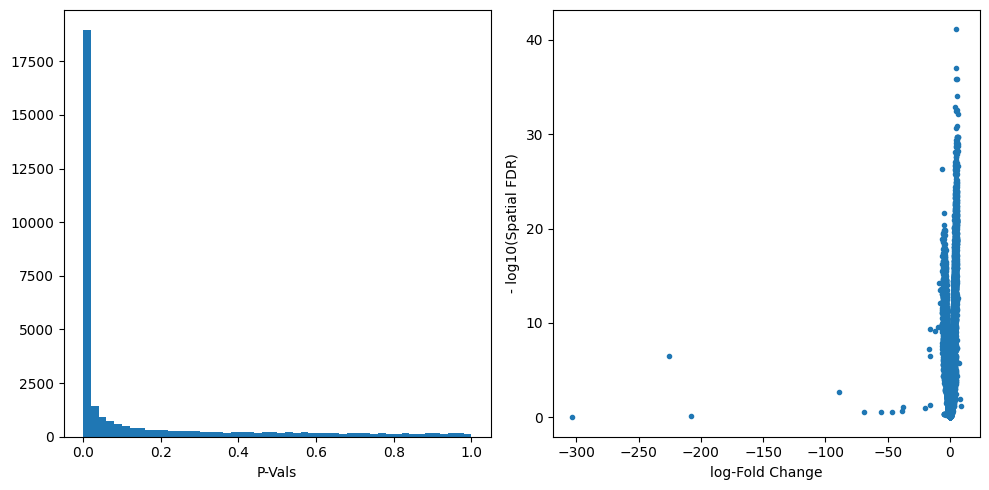

In [ ]:
# Plot p-value distribution and logFC versus spatial FDR for model diagnostics
old_figsize = plt.rcParams["figure.figsize"]
plt.rcParams["figure.figsize"] = [10, 5]
plt.subplot(1, 2, 1)
plt.hist(mdata_cd4_age["milo"].var.PValue, bins=50)
plt.xlabel("P-Vals")
plt.subplot(1, 2, 2)
plt.plot(mdata_cd4_age["milo"].var.logFC, -np.log10(mdata_cd4_age["milo"].var.SpatialFDR), ".")
plt.xlabel("log-Fold Change")
plt.ylabel("- log10(Spatial FDR)")
plt.tight_layout()
plt.rcParams["figure.figsize"] = old_figsize

<Axes: xlabel='Age_group'>

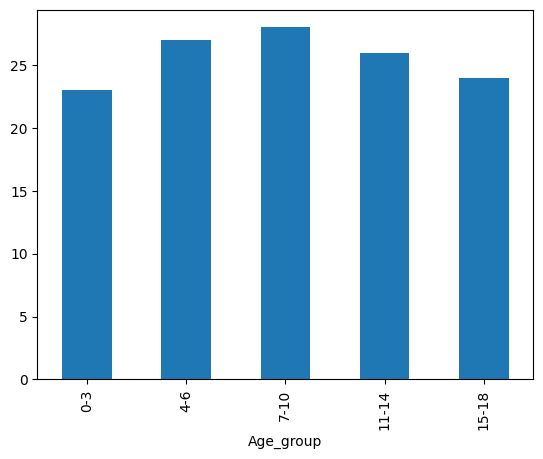

In [ ]:
# Check donor distribution across age groups
mdata_cd4_age["milo"].obs["Age_group"].value_counts().sort_index().plot.bar()

___

## Visualize embedding

In [ ]:
# Build neighbourhood graph for visualising Milo differential abundance results
milo.build_nhood_graph(mdata_cd4_age)


In [8]:
mdata_cd4_age["milo"]

AnnData object with n_obs × n_vars = 128 × 32149
    obs: 'Age_years', 'Batch', 'Sex', 'pica_id', 'Age_group'
    var: 'index_cell', 'kth_distance', 'logCPM', 'logFC', 'PValue', 'FDR', 'SpatialFDR', 'Nhood_size'
    uns: 'sample_col', 'nhood'
    varm: 'X_milo_graph'
    varp: 'nhood_connectivities'

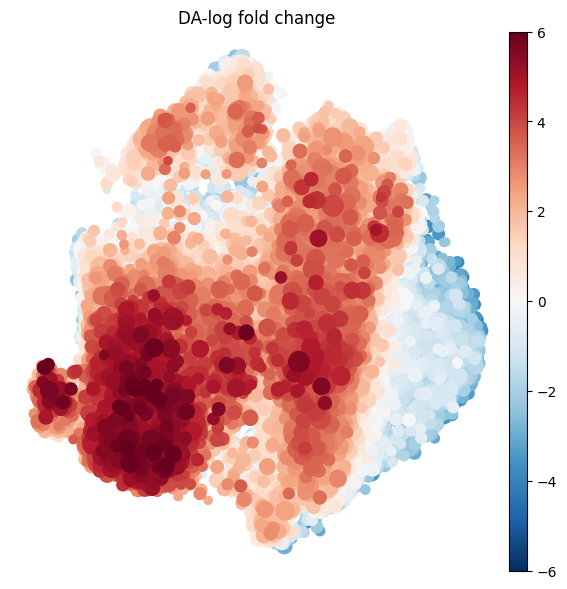

In [ ]:
# Create neighbourhood-level AnnData object for plotting
nhood_adata = ad.AnnData(
    X=np.zeros((mdata_cd4_age["milo"].n_vars, 1)),
    obs=mdata_cd4_age["milo"].var.copy()
)

# Add Milo graph coordinates
nhood_adata.obsm["X_milo_graph"] = mdata_cd4_age["milo"].varm["X_milo_graph"]

# Clip extreme logFC values for clearer visualisation
nhood_adata.obs["logFC_clipped"] = nhood_adata.obs["logFC"].clip(-6, 6)

# Plot neighbourhood-level age-associated logFC values
plt.rcParams["figure.figsize"] = [7, 7]

sc.pl.embedding(
    nhood_adata,
    basis="X_milo_graph",
    color="logFC",
    cmap="RdBu_r",
    vmin=-6,
    vmax=6,
    size=nhood_adata.obs["Nhood_size"],
    frameon=False,
    title="DA-log fold change"
)

___

## Annotate Neighbourhoods by Cell Type

In [ ]:
# Assign dominant CD4 cell-type annotation to each Milo neighbourhood
milo.annotate_nhoods(mdata_cd4_age, anno_col="pica_cell_type_complete_01_gdT_corrected")


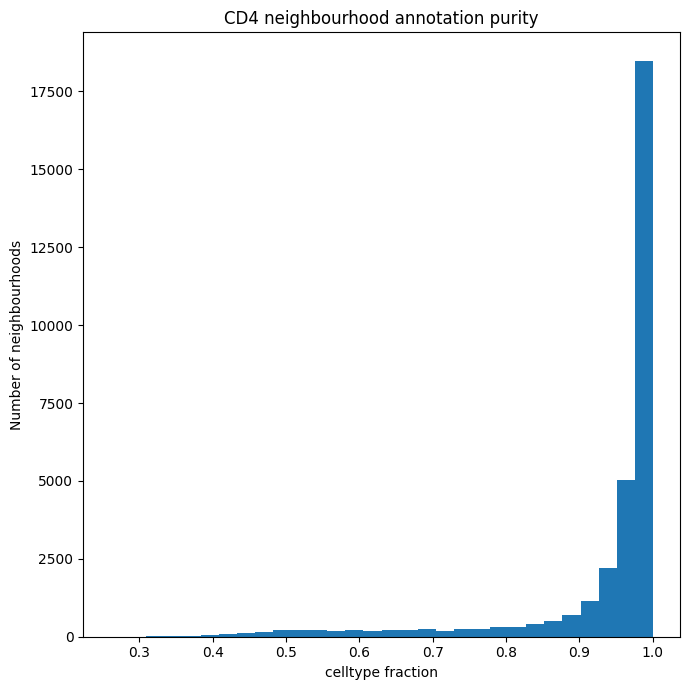

In [ ]:
# Assess annotation purity across neighbourhoods
plt.hist(mdata_cd4_age["milo"].var["nhood_annotation_frac"], bins=30)
plt.xlabel("celltype fraction")
plt.ylabel("Number of neighbourhoods")
plt.title("CD4 neighbourhood annotation purity")
plt.tight_layout()
plt.show()

In [ ]:
# Label low-purity neighbourhoods as mixed to avoid over-interpreting ambiguous neighbourhoods
if "Mixed" not in mdata_cd4_age["milo"].var["nhood_annotation"].cat.categories:
    mdata_cd4_age["milo"].var["nhood_annotation"] = mdata_cd4_age["milo"].var["nhood_annotation"].cat.add_categories("Mixed")

mdata_cd4_age["milo"].var.loc[
    mdata_cd4_age["milo"].var["nhood_annotation_frac"] < 0.6, 
    "nhood_annotation"
] = "Mixed"

### Filter and Summarise Significant Neighbourhoods

In [ ]:
# Remove extreme logFC outliers for downstream plotting
df_cd4_age = (
    mdata_cd4_age["milo"].var
    .query("abs(logFC) < 50")
    .copy()
)

df_cd4_age["sig"] = df_cd4_age["SpatialFDR"] < 0.1

print(f"Nhoods before filter: {len(mdata_cd4_age['milo'].var)}")
print(f"Nhoods after filter: {len(df_cd4_age)}")
print(f"Removed: {len(mdata_cd4_age['milo'].var) - len(df_cd4_age)} extreme outlier nhoods")

Nhoods before filter: 32149
Nhoods after filter: 32143
Removed: 6 extreme outlier nhoods


In [ ]:
# Extract significant age-associated neighbourhoods
sig_nhoods_cd4_age = df_cd4_age.query("SpatialFDR < 0.1").copy()

In [ ]:
# Inspect top age-enriched CD4 neighbourhoods
sig_nhoods_cd4_age.sort_values("logFC", ascending=False).head()

,index_cell,kth_distance,logCPM,logFC,PValue,FDR,SpatialFDR,Nhood_size,nhood_annotation,nhood_annotation_frac,sig
30952,20241106_WGS_20241106_sc_PICA0033-PICA0069_Poo...,3.811722,4.406093,8.540003,4.404244e-02,6.886102e-02,6.913429e-02,359.0,CD4 cytoT,0.994429,True
30740,20241106_WGS_20241106_sc_PICA0033-PICA0069_Poo...,3.912332,4.602364,7.938146,6.679933e-03,1.258737e-02,1.265944e-02,382.0,CD4 cytoT,0.984293,True
30915,20241106_WGS_20241106_sc_PICA0033-PICA0069_Poo...,3.733798,5.380626,7.220033,4.222554e-07,1.810495e-06,1.838895e-06,472.0,CD4 cytoT,0.995763,True
5177,20250114_WGS_20241218_sc_PICA0071-PICA0097_Poo...,3.831948,4.613301,6.530949,1.404937e-32,1.672864e-29,1.821399e-29,607.0,CD4 Tem,0.973641,True
16757,20250324_WGS_20250324_sc_PICA0098-PICA0118_Poo...,3.770185,3.971986,6.448938,5.778955e-32,5.996621e-29,6.534743e-29,608.0,CD4 Tem,0.998355,True


In [ ]:
# Summarise significant neighbourhoods by annotation and direction of age effect
sig_summary_cd4_age = (
    sig_nhoods_cd4_age
    .assign(direction=lambda x: np.where(x["logFC"] > 0, "Enriched", "Depleted"))
    .groupby(["nhood_annotation", "direction"])
    .size()
    .unstack(fill_value=0)
)

sig_summary_cd4_age["Total"] = sig_summary_cd4_age.sum(axis=1)

/scratch/temp/24562169/ipykernel_408349/4198698154.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["nhood_annotation", "direction"])


In [ ]:
# Save directional summary table and display results
sig_summary_cd4_age.to_csv(
    "/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/03_milo/cd4_sig_nhood_age_direction_summary.csv"
)

display(sig_summary_cd4_age)

direction,Depleted,Enriched,Total
nhood_annotation,,,
CD4 Tem,113,3633,3746
CD4 cytoT,15,234,249
CD4 naive/Tcm,9259,5226,14485
Tfh,335,667,1002
Treg,704,521,1225
Mixed,183,668,851


In [30]:
sig_nhoods_cd4_age.to_csv("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/03_milo/cd4_sig_nhood_age_milo_results.csv")

___

## Diagnostic Visualisation of Age Effects

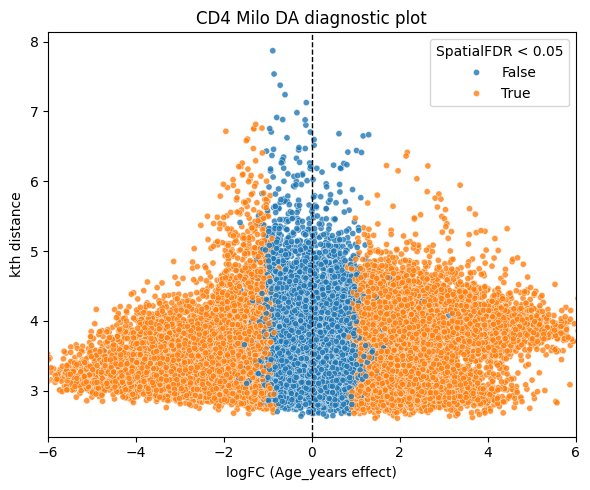

In [ ]:
# Visualise relationship between age-associated logFC and neighbourhood distance
plt.figure(figsize=(6, 5))

sns.scatterplot(
    data=df_cd4_age,
    x="logFC",
    y="kth_distance",
    hue=df_cd4_age["SpatialFDR"] < 0.05,
    s=20,
    alpha=0.8
)

plt.axvline(0, linestyle="--", color="black", linewidth=1)
plt.xlim(-6, 6)
plt.xlabel("logFC (Age_years effect)")
plt.ylabel("kth distance")
plt.title("CD4 Milo DA diagnostic plot")
plt.legend(title="SpatialFDR < 0.05")
plt.tight_layout()
plt.show()

___

## Visualization

### Age-Associated Neighbourhoods

In [ ]:
# Select top age-enriched neighbourhoods for count visualisation
pl_nhood_cd4_age_pos = (
    df_cd4_age
    .query("SpatialFDR < 0.1")
    .sort_values("logFC", ascending=False)
    .index[:6]
)

# Select top age-depleted neighbourhoods for count visualisation
pl_nhood_cd4_age_neg = (
    df_cd4_age
    .query("SpatialFDR < 0.1")
    .sort_values("logFC", ascending=True)
    .index[:6]
)

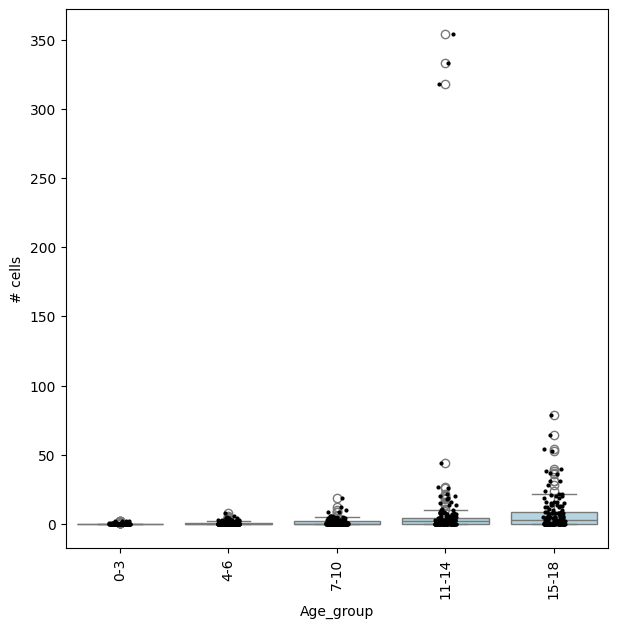

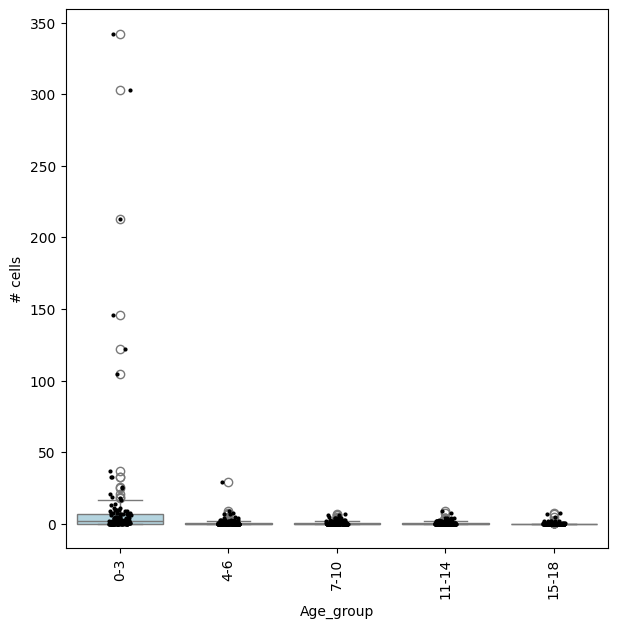

In [ ]:
# Visualise counts by age group for top age-enriched neighbourhoods
milo.plot_nhood_counts_by_cond(
    mdata_cd4_age,
    test_var="Age_group",
    subset_nhoods=pl_nhood_cd4_age_pos,
    log_counts=False
)

# Visualise counts by age group for top age-depleted neighbourhoods
milo.plot_nhood_counts_by_cond(
    mdata_cd4_age,
    test_var="Age_group",
    subset_nhoods=pl_nhood_cd4_age_neg,
    log_counts=False
)

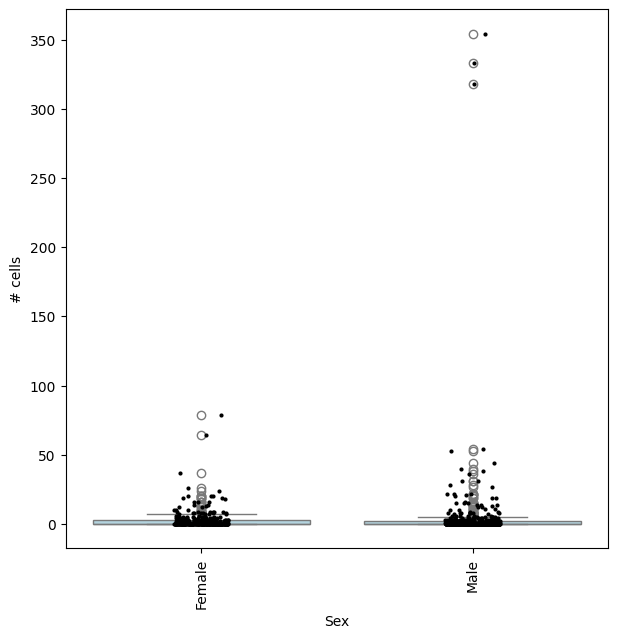

In [ ]:
# Visualise counts by sex for top age-enriched neighbourhoods as an exploratory check
milo.plot_nhood_counts_by_cond(
    mdata_cd4_age,
    test_var="Sex",
    subset_nhoods=pl_nhood_cd4_age_pos,
    log_counts=False
)

### logFC Distribution by Neighbourhood Annotation

/scratch/temp/24562169/ipykernel_408349/3067565206.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cd4_age.groupby("nhood_annotation")["logFC"]
/scratch/temp/24562169/ipykernel_408349/3067565206.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sig_df.groupby(["nhood_annotation", "direction"])


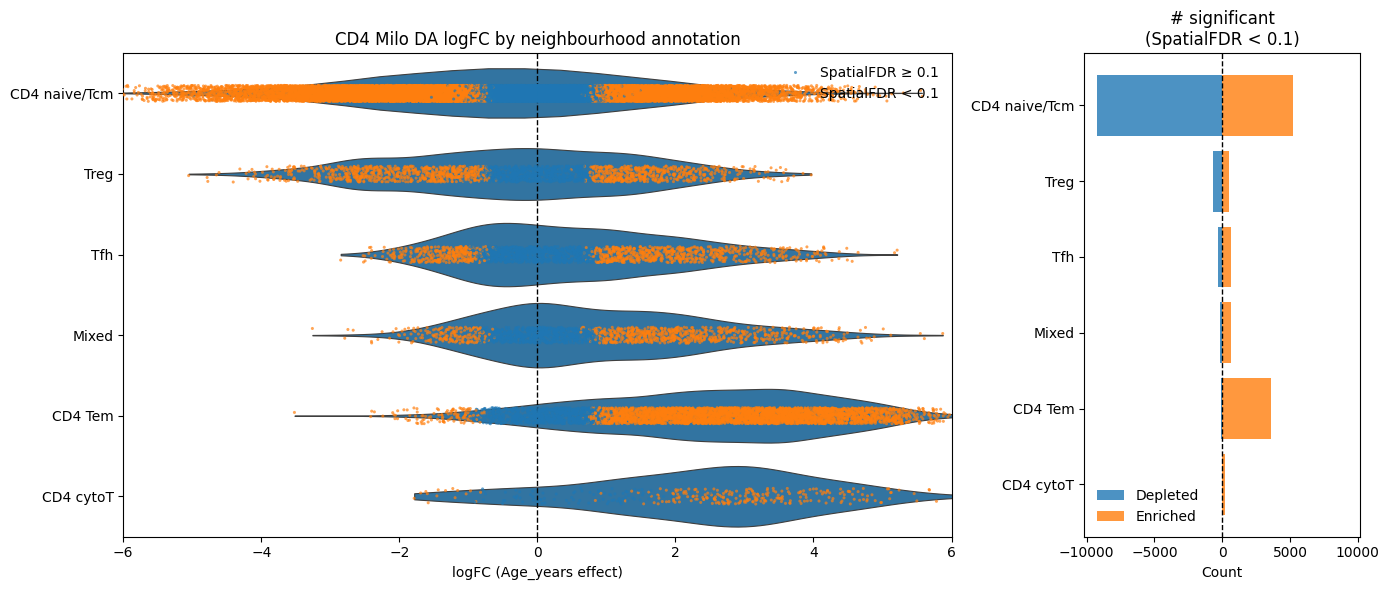

In [49]:
# full nhood results
# order annotations by median logFC (most depleted on top)
order = (
    df_cd4_age.groupby("nhood_annotation")["logFC"]
    .median()
    .sort_values()
    .index
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios":[3, 1]})

# ---- Panel A: logFC distribution by annotation ----
sns.violinplot(
    data=df_cd4_age,
    y="nhood_annotation",
    x="logFC",
    order=order,
    inner=None,
    cut=0,
    linewidth=0.8,
    ax=axes[0]
)

sns.stripplot(
    data=df_cd4_age,
    y="nhood_annotation",
    x="logFC",
    order=order,
    hue="sig",
    dodge=False,
    size=2.2,
    alpha=0.7,
    ax=axes[0]
)

axes[0].axvline(0, linestyle="--", color="black", linewidth=1)
axes[0].set_title("CD4 Milo DA logFC by neighbourhood annotation")
axes[0].set_xlabel("logFC (Age_years effect)")
axes[0].set_ylabel("")

# Visual zoom only — does not alter statistics
axes[0].set_xlim(-6, 6)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(
    handles[:2],
    ["SpatialFDR ≥ 0.1", "SpatialFDR < 0.1"],
    title="",
    loc="upper right",
    frameon=False
)

# ---- Panel B: bidirectional counts of significant neighbourhoods ----
sig_df = df_cd4_age[df_cd4_age["sig"]].copy()

sig_df["direction"] = np.where(
    sig_df["logFC"] > 0,
    "Enriched",
    "Depleted"
)

sig_counts = (
    sig_df.groupby(["nhood_annotation", "direction"])
    .size()
    .unstack(fill_value=0)
    .reindex(order, fill_value=0)
)

plot_df = sig_counts.copy()

if "Depleted" not in plot_df.columns:
    plot_df["Depleted"] = 0

if "Enriched" not in plot_df.columns:
    plot_df["Enriched"] = 0

plot_df["Depleted"] = -plot_df["Depleted"]

axes[1].barh(
    plot_df.index,
    plot_df["Depleted"],
    label="Depleted",
    alpha=0.8
)

axes[1].barh(
    plot_df.index,
    plot_df["Enriched"],
    label="Enriched",
    alpha=0.8
)

axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("# significant\n(SpatialFDR < 0.1)")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")

max_count = np.abs(plot_df[["Depleted", "Enriched"]].values).max()
axes[1].set_xlim(-max_count * 1.1, max_count * 1.1)

axes[1].set_yticks(range(len(order)))
axes[1].set_yticklabels(order)
axes[1].invert_yaxis()

axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()